# parameter Value

In [31]:
# =========================
# Session 1 — Common params
# =========================
from dataclasses import dataclass
from typing import Dict, Tuple
import numpy as np

@dataclass
class PaperParamsWaterS3:
    # ---- paper-fixed (S3) ----
    s_cm: float = 0.5
    gamma_mo: float = 12.8
    gamma_cm: float = 2.6
    gamma_co: float = 15.4          # = 12.8 + 2.6
    f0: float = 1.0e5
    g0: float = 2.0e7
    C1_prefactor: float = 1.6e21    # C1 = C1_prefactor * exp(s_co)
    # ---- numerics (defaults) ----
    M: int = 240
    t_max_dimless: float = 60.0      # τ = f0 t
    dt_dimless: float = 2e-2
    max_w: float = 1e3               # cap for w to avoid overflow
    clip_exp: float = 80.0           # clip for exp(ΔlnC)

PAPER = PaperParamsWaterS3()

def make_params_for_sco(s_co: float,
                        *, M=None, t_max=None, dt=None, clip=None) -> Dict:
    """Create a param dict for a given s_co (everything derived here)."""
    s_om = max(1e-12, s_co - PAPER.s_cm)
    C1   = PAPER.C1_prefactor * np.exp(s_co)
    lnC1 = np.log(C1)
    return {
        # thermo
        "s_om": s_om, "s_cm": PAPER.s_cm,
        "gamma_om": PAPER.gamma_mo, "gamma_cm": PAPER.gamma_cm, "gamma_co": PAPER.gamma_co,
        # kinetics in dimless time τ=f0 t  → f1=1, g1=g0/f0, k1=1
        "f1": 1.0, "g1": PAPER.g0/PAPER.f0, "k1": 1.0,
        "alpha": 2/3, "beta": 2/3, "eps": 2/3,
        # concentration scale (log)
        "C1": C1, "lnC1": lnC1,
        # numerics
        "M": PAPER.M if M is None else M,
        "t_max": PAPER.t_max_dimless if t_max is None else t_max,
        "dt": PAPER.dt_dimless if dt is None else dt,
        "fixed_C1": True,
        "max_w": PAPER.max_w,
        "clip_exp": PAPER.clip_exp if clip is None else clip,
    }

# small utilities shared by all sessions
def build_triangle(M: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    I, N = np.indices((M+1, M+1))
    tri = (I>=1) & (N>=1) & (N<=I)
    return I*tri, N*tri, tri

def i_star_co(p: Dict) -> float:
    s_co = p["s_cm"] + p["s_om"]
    return (2 * p["gamma_co"] / (3 * s_co))**3

def n_star_cm(p: Dict) -> float:
    return (2 * p["gamma_cm"] / (3 * p["s_cm"]))**3

def validate_params(p: Dict):
    assert p["s_om"]>0 and p["s_cm"]>0
    assert p["gamma_om"]>0 and p["gamma_cm"]>0 and p["gamma_co"]>0
    assert np.isclose(p["gamma_co"], p["gamma_om"]+p["gamma_cm"], atol=1e-8), "γ_co must equal γ_om+γ_cm"
    assert p["f1"]>0 and p["g1"]>0 and p["k1"]>0


# 공통 Wi,n & Ci,n

In [32]:
# ========================================
# Session 2 — Work of formation & ln C_eq
# ========================================
def w_in(I: np.ndarray, N: np.ndarray, p: Dict) -> np.ndarray:
    """
    w_{i,n} = [-s_om i + γ_om i^{2/3}] + [-s_cm n + γ_cm n^{2/3}]  (Eq. 15)
    """
    I = np.asarray(I, float); N = np.asarray(N, float)
    wi = -p["s_om"]*I + p["gamma_om"]*np.power(np.maximum(I,1), 2/3)
    wn = -p["s_cm"]*N + p["gamma_cm"]*np.power(np.maximum(N,1), 2/3)
    return np.clip(wi+wn, -p["max_w"], p["max_w"])

def lnC_equil(I: np.ndarray, N: np.ndarray, tri: np.ndarray, p: Dict) -> np.ndarray:
    """
    ln C_{i,n} = ln C1 - (w_{i,n} - w_{1,1})  (Eq. 25) — stored in log for stability.
    """
    W   = w_in(I, N, p)
    w11 = w_in(1.0, 1.0, p)
    lnC = np.full_like(I, -np.inf, dtype=float)
    lnC[tri] = p["lnC1"] - (W[tri] - w11)
    return lnC


# Work of formation

[warn] dt*max(rate) = 0.772 > 0.2; subcycling.


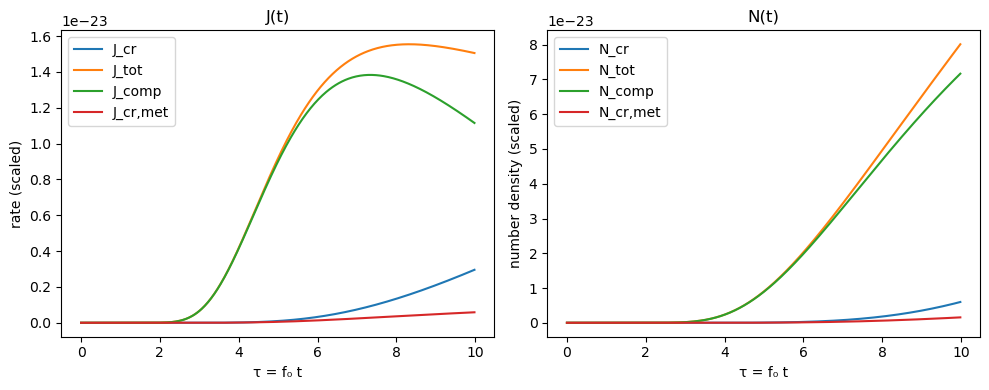

In [37]:
# =========================================
# Utilities (공통 유틸: 안전지수/표준화/격자/평형분포)
# =========================================
import numpy as np
from typing import Dict, Tuple

# ----- 수치 안전 유틸 -----
def safe_log(x, eps=1e-300):
    return np.log(np.clip(x, eps, None))

def safe_exp(x, clip=700.0):
    # exp clip: exp(±700) ~ 1e±304
    return np.exp(np.clip(x, -clip, clip))

def exp_diff(A, B, clip=700.0):
    """exp(A-B) with clipping"""
    return safe_exp(A - B, clip=clip)

# ----- 파라미터/시뮬 결과 표준화 -----
def normalize_params(p: Dict) -> Dict:
    """필수/파생 파라미터를 표준 키로 보정하고 과거 호환 처리."""
    q = dict(p)

    # 과거 키 호환: 소문자 'c'가 오면 C1로 간주 (가능하면 원본에서 제거 권장)
    if 'c' in q and 'C1' not in q:
        q['C1'] = q['c']

    # 필수 기본값
    q.setdefault('alpha', 2/3); q.setdefault('beta', 2/3); q.setdefault('eps', 2/3)
    q.setdefault('f1', 1.0);    q.setdefault('g1', 1.0);   q.setdefault('k1', 1.0)

    # 시뮬 제어 기본값
    q.setdefault('dt', 2e-2); q.setdefault('t_max', 10.0); q.setdefault('M', 240)
    q.setdefault('clip_exp', 80.0); q.setdefault('fixed_C1', True)
    q.setdefault('subcycle_safety', 0.2)  # dt * max(rate) <= safety
    q.setdefault('use_subcycling', True)

    # 열역학 파생량
    if 's_co' not in q and 's_cm' in q and 's_mo' in q:
        q['s_co'] = q['s_cm'] + q['s_mo']
    if 'gamma_co' not in q and 'gamma_cm' in q and 'gamma_mo' in q:
        q['gamma_co'] = q['gamma_cm'] + q['gamma_mo']

    return q

def normalize_sim(sim: Dict) -> Dict:
    """시뮬 dict 키 보정(과거 'c'→'C')."""
    s = dict(sim)
    if 'c' in s and 'C' not in s:
        s['C'] = s['c']
    return s

# ----- 격자 및 마스크 -----
def build_triangle(M: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # 1-based 인덱싱을 쓰기 위해 (M+1)x(M+1)
    I, N = np.meshgrid(np.arange(M+1), np.arange(M+1), indexing='ij')
    tri = (I >= 1) & (N >= 1) & (N <= I) & (I <= M)
    return I, N, tri

# ----- i*, n* (Gibbs–Thomson) -----
def i_star_co(p: Dict) -> float:
    # i*_co = (2 γ_co / (3 s_co))^3
    return (2.0 * p['gamma_co'] / (3.0 * max(p['s_co'], 1e-300)))**3

def n_star_cm(p: Dict) -> float:
    # n*_cm = (2 γ_cm / (3 s_cm))^3
    return (2.0 * p['gamma_cm'] / (3.0 * max(p['s_cm'], 1e-300)))**3

# ----- ln C_eq(i,n) (상수항은 상쇄되므로 0 기준) -----
def lnC_equil(I, N, tri, p: Dict) -> np.ndarray:
    """Eq.(25) with Eq.(15): ln C_{i,n} = const − (w_{i,n} − w_{1,1}). 
       const는 차분에서 소거 → 0으로 두어도 무방."""
    # w_{i,n} = - s_mo * i + γ_mo * i^(2/3)  - s_cm * n + γ_cm * n^(2/3)
    i = I.astype(float)
    n = N.astype(float)
    w = (-p['s_mo'] * i + p['gamma_mo'] * np.power(np.maximum(i,1.0), 2.0/3.0)
         - p['s_cm'] * n + p['gamma_cm'] * np.power(np.maximum(n,1.0), 2.0/3.0))
    w11 = (-p['s_mo'] * 1.0 + p['gamma_mo'] * 1.0
           - p['s_cm'] * 1.0 + p['gamma_cm'] * 1.0)
    lnC = np.zeros_like(w, dtype=float)
    lnC[tri] = -(w[tri] - w11)  # const=0 기준
    lnC[~tri] = -np.inf         # 물리적 영역 밖은 0
    return lnC

# =================================
# Session 3 — Master equation (개정)
# =================================
def simulate_master_eq(p_in: Dict, snap_times=(5.0, 10.0, 60.0)) -> Dict:
    """
    Explicit Euler(+optional subcycling) integration of the 2S master equation.
    - Fluxes I,G,K use lnC 차분 형태로 overflow 방지
    - 분포 Z는 C1로 스케일 → Z[1,1]=1 (저장고)
    - 경계 조건: Eqs.(26)–(32) 부호 검증 반영
    """
    p = normalize_params(p_in)
    I, N, tri  = build_triangle(p["M"])
    lnC        = lnC_equil(I, N, tri, p)

    # rates in τ time (power laws)
    F = np.zeros_like(I, float); G = np.zeros_like(N, float); K = np.zeros_like(I, float)
    mI=(I>=1); mN=(N>=1)
    F[mI] = p["f1"]*np.power(np.maximum(I,1), p["alpha"])[mI]
    G[mN] = p["g1"]*np.power(np.maximum(N,1), p["beta"])[mN]
    K[mI] = p["k1"]*np.power(np.maximum(I,1), p["eps"])[mI]

    # stability / subcycling
    lam = max(F[mI].max(initial=0), G[mN].max(initial=0), K[mI].max(initial=0))
    if p["dt"]*lam > p["subcycle_safety"]:
        print(f"[warn] dt*max(rate) = {p['dt']*lam:.3f} > {p['subcycle_safety']}; "
              f"{'subcycling' if p['use_subcycling'] else 'consider reducing dt'}.")

    # scaled distribution: Z' = Z / C1  → reservoir is 1.0
    Z = np.zeros_like(I, float); Z[1,1] = 1.0

    n_steps = max(1, int(np.ceil(p["t_max"]/p["dt"])))
    times   = np.arange(n_steps, dtype=float) * p["dt"]
    snap_ts = sorted([t for t in snap_times if t < p["t_max"]] + [p["t_max"]-1e-12])
    snaps   = {t: None for t in snap_ts}

    I_series, G_series, K_series = [], [], []

    def single_update(Z):
        # forward fluxes (from (i,n) to larger sizes)
        I_fwd = np.zeros_like(Z); mIf = tri & (I+1<=p["M"])
        I_fwd[mIf] = F[mIf]*( Z[mIf] - Z[(I+1)[mIf], N[mIf]] * exp_diff(lnC[mIf], lnC[(I+1)[mIf], N[mIf]], p["clip_exp"]) )

        G_fwd = np.zeros_like(Z); mGf = tri & (N+1<=I)
        G_fwd[mGf] = G[mGf]*( Z[mGf] - Z[I[mGf], (N+1)[mGf]] * exp_diff(lnC[mGf], lnC[I[mGf], (N+1)[mGf]], p["clip_exp"]) )

        K_fwd = np.zeros_like(Z); diag = tri & (N==I) & (I+1<=p["M"])
        K_fwd[diag]= K[diag]*( Z[diag] - Z[(I+1)[diag], (N+1)[diag]] * exp_diff(lnC[diag], lnC[(I+1)[diag], (N+1)[diag]], p["clip_exp"]) )

        # dZ = inflow − outflow
        dZ = np.zeros_like(Z)

        interior = tri & (N>=2) & (N<=I-1) & (I>=3) & (I<=p["M"]-1)
        dZ[interior] = (I_fwd[I[interior]-1, N[interior]] - I_fwd[interior]) + \
                       (G_fwd[I[interior],   N[interior]-1] - G_fwd[interior])

        # boundary n=1: inflow I_{i-1,1}, outflow I_{i,1}, G는 n=2로 유출(−)
        b_n1 = tri & (N==1) & (I>=2) & (I<=p["M"]-1)
        dZ[b_n1] = (I_fwd[I[b_n1]-1, 1] - I_fwd[b_n1]) - G_fwd[b_n1]

        # diagonal n=i: inflow I_{i-1,i}, G_{i,i-1}, K_{i-1,i-1}; outflow I_{i,i}, K_{i,i}
        b_diag = tri & (N==I) & (I>=2) & (I<=p["M"]-1)
        dZ[b_diag] = (I_fwd[I[b_diag]-1, N[b_diag]] - I_fwd[b_diag]) + \
                     G_fwd[I[b_diag], N[b_diag]-1] + \
                     (K_fwd[I[b_diag]-1, I[b_diag]-1] - K_fwd[b_diag])

        return I_fwd, G_fwd, K_fwd, dZ

    for t in times:
        if p["fixed_C1"]:
            Z[1,1] = 1.0

        # ---- subcycling for stability ----
        if p["use_subcycling"] and lam > 0:
            nsub = max(1, int(np.ceil(p["dt"] * lam / p["subcycle_safety"])))
        else:
            nsub = 1
        dts = p["dt"] / nsub

        # store last fluxes of this step
        I_fwd = G_fwd = K_fwd = None

        for _ in range(nsub):
            I_fwd, G_fwd, K_fwd, dZ = single_update(Z)
            if p["fixed_C1"]:
                dZ[1,1] = 0.0
            Z[tri] += dts * dZ[tri]
            # non-negativity
            Z[Z < 0] = 0.0
            if p["fixed_C1"]:
                Z[1,1] = 1.0

        # 기록
        I_series.append((I_fwd if I_fwd is not None else np.zeros_like(Z)))
        G_series.append((G_fwd if G_fwd is not None else np.zeros_like(Z)))
        K_series.append((K_fwd if K_fwd is not None else np.zeros_like(Z)))

        # 스냅샷
        for ts in list(snaps.keys()):
            if snaps[ts] is None and t + 1e-12 >= ts:
                snaps[ts] = Z.copy()

    return normalize_sim({
        "I": I, "N": N, "tri": tri,
        "lnC": lnC,
        "Zsnaps": snaps,
        "times": times,
        "I_series": np.array(I_series),
        "G_series": np.array(G_series),
        "K_series": np.array(K_series),
    })

# ==============================
# Session 4 — Nucleation rate (개정)
# ==============================
def compute_J_series(sim_in: Dict, p_in: Dict) -> Dict[str, np.ndarray]:
    sim = normalize_sim(sim_in)
    p   = normalize_params(p_in)

    I, N, tri = sim["I"], sim["N"], sim["tri"]
    I_ser, G_ser, K_ser, times = sim["I_series"], sim["G_series"], sim["K_series"], sim["times"]
    T = len(times)

    ico = int(np.ceil(i_star_co(p)))
    nst = int(np.ceil(n_star_cm(p)))

    on_diag   = tri & (N==I)
    row_ico   = tri & (I==ico)
    above_ico = tri & (I>=ico+1)
    ii_minus  = tri & (N==I-1)
    n_eq_nst  = tri & (N==nst)

    J_cr  = np.zeros(T)   # crystals (diagonal) supernuclei
    J_tot = np.zeros(T)   # total supernuclei across i=ico
    J_comp= np.zeros(T)   # composite supernuclei
    J_cmet= np.zeros(T)   # crystals inside composites

    for t in range(T):
        I_fwd, G_fwd, K_fwd = I_ser[t], G_ser[t], K_ser[t]
        # J_cr: +K(diag,i>=ico) +G((i,i-1)->(i,i),i>=ico) − I(diag,i>=ico)
        term_K = np.sum(np.maximum(K_fwd[ on_diag & (I>=ico) ], 0.0))
        term_G = np.sum(np.maximum(G_fwd[ ii_minus & (I>=ico) ], 0.0))
        term_I = np.sum(np.maximum(I_fwd[ on_diag & (I>=ico) ], 0.0))
        J_cr[t] = term_K + term_G - term_I

        # J_tot: +K(diag,i=ico) + I(i=ico, all n)
        term_Kt = np.sum(np.maximum(K_fwd[ on_diag & (I==ico) ], 0.0))
        term_It = np.sum(np.maximum(I_fwd[ row_ico & (N>=1) ], 0.0))
        J_tot[t]  = term_Kt + term_It

        # J_comp: +I(i=ico, all n) − I(diag,i>=ico) − G((i,i-1),i>=ico)
        J_comp[t] = term_It - term_I - term_G

        # J_cr,met: +G(n=n*, i>=ico+1) − G(n=i−1, i>=ico+1) + I(diag,i>=ico)
        term_Gplus  = np.sum(np.maximum(G_fwd[ n_eq_nst & above_ico ], 0.0))
        term_Gminus = np.sum(np.maximum(G_fwd[ ii_minus  & above_ico ], 0.0))
        J_cmet[t] = term_Gplus - term_Gminus + term_I

    return {"t": times, "J_cr": J_cr, "J_tot": J_tot, "J_comp": J_comp, "J_cr_met": J_cmet}

def integrate_J_to_N(t: np.ndarray, J: np.ndarray) -> np.ndarray:
    if len(t) < 2: return np.zeros_like(t)
    dt = t[1] - t[0]
    N = np.cumsum((J[:-1] + J[1:]) * 0.5 * dt)
    return np.concatenate([[0.0], N])

# ----- (optional) quick plot -----
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # 예시 파라미터(필요 시 Session 1에서 가져와 덮어쓰기)
    p0 = dict(
        s_mo=2.0, s_cm=0.6,  # s_co는 자동 계산
        gamma_mo=12.0, gamma_cm=2.5,  # gamma_co 자동 계산
        C1=1.0,
        dt=2e-2, t_max=10.0, M=240, clip_exp=80.0,
        fixed_C1=True, use_subcycling=True, subcycle_safety=0.2,
        f1=1.0, g1=1.0, k1=1.0, alpha=2/3, beta=2/3, eps=2/3,
    )
    # s_co는 내부에서 s_cm+s_mo로 자동 설정
    p = normalize_params(p0)

    sim   = simulate_master_eq(p, snap_times=(2.0, 6.0, 9.5))
    rates = compute_J_series(sim, p)
    t = rates["t"]
    J_cr, J_tot, J_comp, J_cmet = rates["J_cr"], rates["J_tot"], rates["J_comp"], rates["J_cr_met"]
    N_cr   = integrate_J_to_N(t, J_cr)
    N_tot  = integrate_J_to_N(t, J_tot)
    N_comp = integrate_J_to_N(t, J_comp)
    N_cmet = integrate_J_to_N(t, J_cmet)

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
    ax1.plot(t, J_cr, label="J_cr"); ax1.plot(t, J_tot, label="J_tot")
    ax1.plot(t, J_comp, label="J_comp"); ax1.plot(t, J_cmet, label="J_cr,met")
    ax1.set_xlabel("τ = f₀ t"); ax1.set_ylabel("rate (scaled)"); ax1.set_title("J(t)"); ax1.legend()

    ax2.plot(t, N_cr, label="N_cr"); ax2.plot(t, N_tot, label="N_tot")
    ax2.plot(t, N_comp, label="N_comp"); ax2.plot(t, N_cmet, label="N_cr,met")
    ax2.set_xlabel("τ = f₀ t"); ax2.set_ylabel("number density (scaled)"); ax2.set_title("N(t)"); ax2.legend()
    plt.tight_layout(); plt.show()


Simulating...
[warn] dt*max(rate) = 0.772 > 0.2; subcycling.
Computing rates...
Steady-state J_tot (J_ss): 1.046e-23
Induction Time (Theta_tot): -0.500


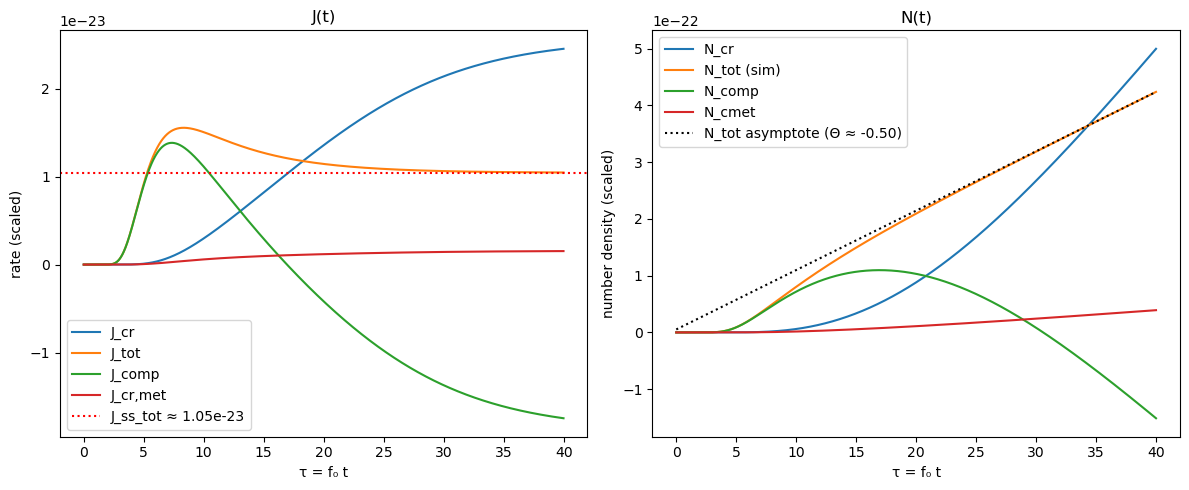

In [38]:
# ==============================
# Session 4 — Nucleation rate (개정)
# ... (이전 코드) ...
# ----- (optional) quick plot -----
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # 예시 파라미터 (t_max를 10.0 -> 40.0으로 늘려서 정상 상태 도달 확인)
    p0 = dict(
        s_mo=2.0, s_cm=0.6,
        gamma_mo=12.0, gamma_cm=2.5,
        C1=1.0,
        dt=2e-2, t_max=40.0,  # <-- 시뮬레이션 시간을 40으로 늘림
        M=240, clip_exp=80.0,
        fixed_C1=True, use_subcycling=True, subcycle_safety=0.2,
        f1=1.0, g1=1.0, k1=1.0, alpha=2/3, beta=2/3, eps=2/3,
    )
    p = normalize_params(p0)

    print("Simulating...")
    sim = simulate_master_eq(p, snap_times=(10.0, 20.0, 39.0))
    print("Computing rates...")
    rates = compute_J_series(sim, p)
    
    t = rates["t"]
    J_cr, J_tot, J_comp, J_cmet = rates["J_cr"], rates["J_tot"], rates["J_comp"], rates["J_cr_met"]
    N_cr = integrate_J_to_N(t, J_cr)
    N_tot = integrate_J_to_N(t, J_tot)
    N_comp = integrate_J_to_N(t, J_comp)
    N_cmet = integrate_J_to_N(t, J_cmet)

    # ======== 참고 문헌 스타일 플롯을 위한 계산 (START) ========
    # J_ss (Steady-state J) : J_tot의 마지막 값으로 근사
    J_ss_tot = J_tot[-1]
    
    # Induction Time (Theta) 계산: N_ss(t) ≈ J_ss * (t - Θ)
    # Θ ≈ t - N(t) / J_ss (정상 상태에 도달했을 때의 값 사용)
    t_final = t[-1]
    N_final_tot = N_tot[-1]
    
    # J_ss가 0에 가까우면 ZeroDivisionError 방지
    induction_time_tot = 0.0
    if J_ss_tot > 1e-300:
        induction_time_tot = t_final - (N_final_tot / J_ss_tot)
    
    # N(t)의 점근선(asymptote) 계산: N = J_ss * (t - Θ)
    # t < Θ 인 구간은 0으로 처리
    N_asymptote_tot = J_ss_tot * np.maximum(0, t - induction_time_tot)
    
    print(f"Steady-state J_tot (J_ss): {J_ss_tot:.3e}")
    print(f"Induction Time (Theta_tot): {induction_time_tot:.3f}")
    # ======== 참고 문헌 스타일 플롯을 위한 계산 (END) ========

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # --- J(t) 플롯 ---
    ax1.plot(t, J_cr, label="J_cr")
    ax1.plot(t, J_tot, label="J_tot")
    ax1.plot(t, J_comp, label="J_comp")
    ax1.plot(t, J_cmet, label="J_cr,met")
    
    # J_ss (정상 상태) 수평 점선 추가
    ax1.axhline(J_ss_tot, color='r', linestyle=':', label=f'J_ss_tot ≈ {J_ss_tot:.2e}')
    
    ax1.set_xlabel("τ = f₀ t"); ax1.set_ylabel("rate (scaled)"); ax1.set_title("J(t)"); ax1.legend()

    # --- N(t) 플롯 ---
    ax2.plot(t, N_cr, label="N_cr")
    ax2.plot(t, N_tot, label="N_tot (sim)")
    ax2.plot(t, N_comp, label="N_comp")
    ax2.plot(t, N_cmet, label="N_cmet")
    
    # N(t) 점근선(asymptote) 추가 (Fig. 5의 얇은 점선)
    ax2.plot(t, N_asymptote_tot, 'k:', label=f'N_tot asymptote (Θ ≈ {induction_time_tot:.2f})')
    
    ax2.set_xlabel("τ = f₀ t"); ax2.set_ylabel("number density (scaled)"); ax2.set_title("N(t)"); ax2.legend()
    
    plt.tight_layout()
    plt.show()

# 결과 plot

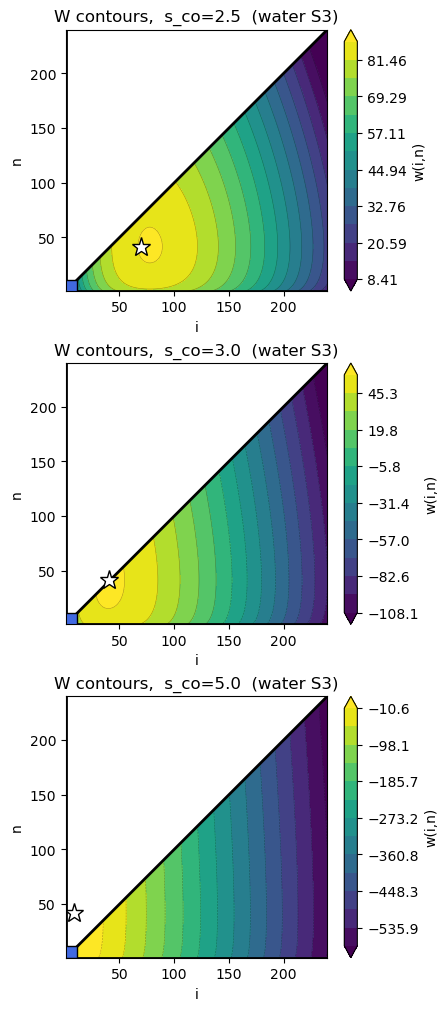

In [35]:
plot_w_contours_for_sco_list((2.5, 3.0, 5.0))

[warn] dt*max(rate) = 154.478 > 0.2; consider reducing dt.


C:\Users\USER\AppData\Local\Temp\ipykernel_8220\313417788.py:49: RuntimeWarning: overflow encountered in multiply
  G_fwd[mGf] = G[mGf]*( Z[mGf] - Z[I[mGf], (N+1)[mGf]] * exp_diff(lnC[mGf], lnC[I[mGf], (N+1)[mGf]]) )
C:\Users\USER\AppData\Local\Temp\ipykernel_8220\313417788.py:61: RuntimeWarning: overflow encountered in subtract
  (G_fwd[I[interior],   N[interior]-1] - G_fwd[interior])
C:\Users\USER\AppData\Local\Temp\ipykernel_8220\313417788.py:75: RuntimeWarning: invalid value encountered in add
  Z[tri] += p["dt"] * dZ[tri]
C:\Users\USER\AppData\Local\Temp\ipykernel_8220\313417788.py:52: RuntimeWarning: invalid value encountered in subtract
  K_fwd[diag]= K[diag]*( Z[diag] - Z[(I+1)[diag], (N+1)[diag]] * exp_diff(lnC[diag], lnC[(I+1)[diag], (N+1)[diag]]) )
C:\Users\USER\AppData\Local\Temp\ipykernel_8220\313417788.py:69: RuntimeWarning: invalid value encountered in add
  dZ[b_diag] = (I_fwd[I[b_diag]-1, N[b_diag]] - I_fwd[b_diag]) + \
C:\Users\USER\AppData\Local\Temp\ipykernel_8220\3

KeyError: 'C'

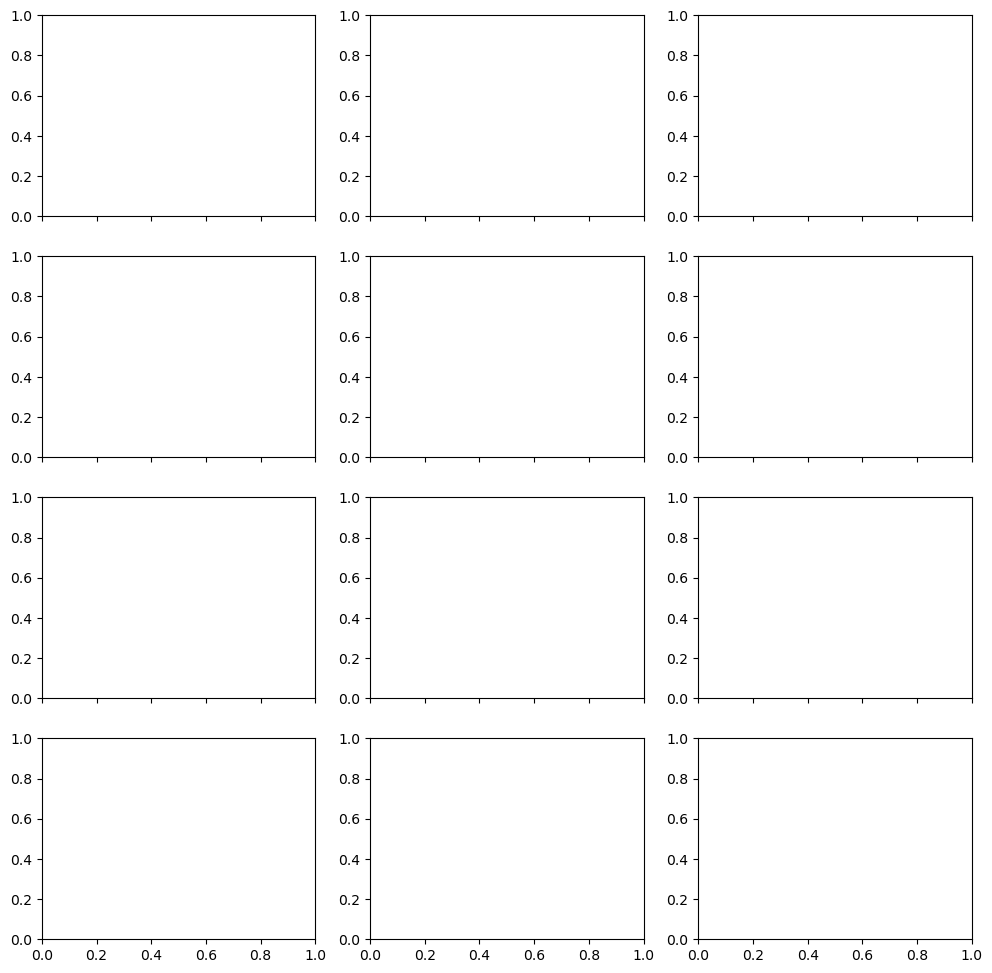

In [36]:
plot_12panels(sco_list=(2.5, 3.0, 5.0), tlist=(5.0, 10.0, 60.0))


In [ ]:
p = make_params_for_sco(3.0)                # s_co 선택
sim = simulate_master_eq(p)                  # Master Eq. 적분
rates = compute_J_series(sim, p)             # J(t)

# J(t) 그리기
import matplotlib.pyplot as plt
t = rates["t"]
plt.figure(); 
plt.plot(t, rates["J_cr"],   label="J_cr")
plt.plot(t, rates["J_tot"],  label="J_tot")
plt.plot(t, rates["J_comp"], label="J_comp")
plt.plot(t, rates["J_cr_met"], label="J_cr,met")
plt.xlabel("τ = f0 t"); plt.ylabel("rate"); plt.legend(); plt.title("J(t)"); plt.show()

# N(t) = ∫J dt 그리기
from math import inf
def integrate_J_to_N(t, J):
    if len(t) < 2: return J*0
    dt = t[1]-t[0]
    import numpy as np
    N = np.cumsum((J[:-1]+J[1:])*0.5*dt)
    return np.concatenate([[0.0], N])

N_tot  = integrate_J_to_N(t, rates["J_tot"])
N_cr   = integrate_J_to_N(t, rates["J_cr"])
N_comp = integrate_J_to_N(t, rates["J_comp"])
N_cmet = integrate_J_to_N(t, rates["J_cr_met"])

plt.figure()
plt.plot(t, N_tot,  label="N_tot")
plt.plot(t, N_cr,   label="N_cr")
plt.plot(t, N_comp, label="N_comp")
plt.plot(t, N_cmet, label="N_cr,met")
plt.xlabel("τ = f0 t"); plt.ylabel("number density"); plt.legend(); plt.title("N(t)"); plt.show()
